# 02 · Physics-Informed Features — Telling the Model What to Listen For

**IUM teaching series, Notebook 2/4** · Wang & Zhao, *Additive Manufacturing*
(2026) 105300.

Raw waveforms have 62,509 points; we have only 50 printed samples. Learning
end-to-end from raw signals is hopeless at this scale (the paper proves it —
Case 1 fails). Instead, the paper *designs* features on a physical map:

![two-scale](https://raw.githubusercontent.com/wangyiquan1010-coder/IUM_teaching_colab/main/figs/two_scale_framework.png)

- **Across layers**: each layer lengthens the acoustic path *and* stiffens the
  material → ToF, amplitude ratio, spectral features encode geometry + material
  state, entangled.
- **Within a layer**: during one 15 s exposure the printhead does not move — the
  path is frozen. The six frames differ *only* through crosslinking → frame-to-
  frame change is a **geometry-immune** probe of curing (→ DoC).

This notebook rebuilds the key features from raw data and then asks, honestly,
how much process information they carry *before any learning* — which turns out
to be a great deal for some of them and very little for others.


### Before we run anything: the setup cell

**Input** — nothing from your side. On Google Colab this cell downloads the
course repository (`github.com/wangyiquan1010-coder/IUM_teaching_colab`), which
ships *all* the data used in this series; running locally, it just finds the
repository folder you already have.

**What this cell does** — clones the repo if needed, moves the working
directory to the repository root (so that every later path like
`data/feature11.csv` resolves), and imports the four things we use everywhere:
`numpy` (signal math), `pandas` (tables), `matplotlib` (plots) and
`ium_utils` — **our own teaching library**, a clean, read-only refactor of the
paper's code that lives in `src/ium_utils.py`. Feel free to open that file at
any point: every function used in the notebooks is defined there, with comments.

**Output** — the imported modules plus a confirmation line printing the
repository root. Nothing is computed yet.


In [1]:
# --- Setup (works both locally and on Google Colab) ---------------------------
# On Colab the notebook starts in an empty machine, so we first download
# ("clone") the whole course repository, which contains the data, the helper
# library and the figures. Locally the files are already next to the notebook,
# so the clone is skipped.
import os, sys

if "google.colab" in sys.modules and not os.path.exists("src"):
    !git clone -q https://github.com/wangyiquan1010-coder/IUM_teaching_colab.git
    %cd IUM_teaching_colab

# Walk up the folder tree until we find the repository root (the folder that
# contains src/). This makes every later path such as "data/feature11.csv"
# work no matter where the notebook was launched from.
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, "src")):
    _parent = os.path.dirname(_here)
    if _parent == _here:
        raise FileNotFoundError("repo root with src/ not found")
    _here = _parent
os.chdir(_here)
sys.path.insert(0, "src")            # so that "import ium_utils" works

import numpy as np                   # arrays / signal math
import pandas as pd                  # tables (features, labels, results)
import matplotlib.pyplot as plt      # static plots
from matplotlib import rc
rc("animation", html="jshtml")       # render animations as interactive players
import ium_utils as iu               # OUR course library (see src/ium_utils.py)
print("setup ok — repo root:", _here)


setup ok — repo root: C:\Users\wangy\Desktop\IUM_teaching_colab


### Loading the controlled pair again

**Input** — the same two `.npz` archives as in Notebook 1: `15L @ I1` (weak
cure) and `15L @ I7` (strong cure). Same geometry, same resin, only the light
intensity differs, so every difference we measure below is a **material**
difference.

**What this cell does** — reloads the waveforms, rebuilds the time axis, and
re-runs the B1/B2 tracker. Each notebook stands on its own, so nothing carries
over from Notebook 1's kernel.

**Output** — `wf_i1`, `wf_i7` (arrays of shape 15 × 6 × 62509), `t_us`, and the
tracking tables `track_i1`, `track_i7` (`b1_idx`, `b2_idx`, `tof_us` per layer)
that every feature below is computed *relative to*.


In [2]:
# Same controlled pair as Notebook 1: identical geometry, different light dose.
wf_i1, _ = iu.load_sample("data/waveforms_15L_I1.npz")   # weak cure
wf_i7, _ = iu.load_sample("data/waveforms_15L_I7.npz")   # strong cure
t_us = iu.time_axis_us()

# Echo positions are the anchor for every feature: all windows below are placed
# relative to the tracked B2 index, never at a fixed absolute time.
track_i1 = iu.track_sample(wf_i1)
track_i7 = iu.track_sample(wf_i7)


## 1. The within-layer scale, animated

Fix one layer. Play its six frames (reference + five during exposure), zoomed
to the B2 echo. The path cannot change — everything you see moving is
**chemistry**.

---

**Input** — one single layer (layer 8) of each print, i.e. `wf_i1[7]` and
`wf_i7[7]`: **6 frames × 62,509 points** each. This time the animation's frames
are the *within-layer* snapshots, not layers.

**What this cell does** — cuts a ±500-sample window (±0.2 µs) centred on that
layer's tracked B2 position and animates the six frames inside it. Because the
printhead does not move during an exposure, the window content can only change
through curing. It also prints the peak-to-peak amplitude of every frame, so
that the discussion below rests on numbers rather than on impressions.

> **Why does the right panel look coarse and "stepped" while the left one looks
> smooth?** Not because one of them is filtered — nothing here is smoothed, and
> both panels are drawn by the same code from the same kind of raw samples. The
> reason is the digitizer's resolution becoming visible:
>
> 1. At this layer the strongly cured print returns a much **weaker echo** —
>    peak-to-peak ≈ 8×10³ against ≈ 4×10⁴ for the weak-cure print, about five
>    times smaller. That is the attenuation effect from Notebook 1.
> 2. The oscilloscope quantizes every sample onto a fixed ladder of levels,
>    about **257 counts apart** in these stored units. So the weak echo is
>    described by only ~32 levels, while the strong one has ~156.
> 3. Each panel is then auto-scaled to its own data, so that its frame-to-frame
>    change stays visible at all. Stretching 32 levels to fill the panel makes
>    the ladder plainly visible as a staircase; 156 levels still read as a
>    smooth curve.
>
> The cell prints both numbers so you can check this rather than take it on
> faith. Two practical consequences: **how much motion you see is not comparable
> across the two panels**, only within one — and the weaker the echo, the more
> of what looks like "signal change" may be quantization.

**Output** — a two-panel animation plus the per-frame amplitudes. What the
numbers show for this layer: in both prints the burst gets *weaker* as the
exposure proceeds (about −8% from the first to the last frame for the weak-cure
print, about −19% for the strongly cured one), while the frame-to-frame change
itself is of similar absolute size in the two prints (a few hundred counts).
Relative to its own, much smaller echo, that makes the strongly cured print's
signal the more *relatively* variable of the two — the opposite of what the
zoomed-out panel alone might suggest.

> Treat this as one layer of one print, not as a rule. Whether within-layer
> motion is systematically larger for weak or for strong cure is exactly the
> kind of question a single animation cannot settle; section 4 looks at all 50
> prints, and Notebook 3 tests it properly.


In [3]:
from matplotlib.animation import FuncAnimation

LAYER = 8                                    # any mid-print layer works
r1, r7 = track_i1.iloc[LAYER-1], track_i7.iloc[LAYER-1]
w1 = 500                                     # half-window: 500 samples = 0.2 µs

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
arts = []
for ax, (wfS, r, name) in zip(axes, [(wf_i1, r1, "I1 (weak cure)"),
                                     (wf_i7, r7, "I7 (strong cure)")]):
    b2 = int(r.b2_idx)                       # window follows the echo, not the clock
    seg_t = t_us[b2-w1:b2+w1]
    block = wfS[LAYER-1, :, b2-w1:b2+w1].astype(float)   # (6 frames, 2*w1)
    # Remove ONE common baseline (the digitizer's DC offset) from all six frames
    # so the burst is centred on zero. Using a single offset for the whole layer
    # leaves the frame-to-frame differences - the thing we came to see - intact.
    block = block - np.median(block)
    # Symmetric limits from the data. (A naive min*1.1 / max*1.1 would clip the
    # trace whenever the window happens to sit entirely below zero.)
    lim = 1.1 * np.abs(block).max()
    ln, = ax.plot([], [], lw=1.2)
    tx = ax.text(0.03, 0.9, "", transform=ax.transAxes)
    # Each panel is auto-scaled to its OWN echo, otherwise the weaker one would
    # be a flat line; the title states the scale so the two stay comparable.
    ax.set(xlim=(seg_t[0], seg_t[-1]), ylim=(-lim, lim), xlabel="time (µs)",
           title=f"{name} — layer {LAYER}\nvertical scale ±{lim:,.0f} a.u.")
    arts.append((ln, tx, seg_t, block))
axes[0].set_ylabel("amplitude (baseline removed)")

def upd(f):
    """Show frame f of the same layer in both panels (f=0 is the reference)."""
    out = []
    for ln, tx, seg_t, block in arts:
        ln.set_data(seg_t, block[f])
        tx.set_text(f"frame {f+1}/6  (t = {max(0,(f-1))*3} s)" if f else "reference")
        out += [ln, tx]
    return out

# Quantify what the animation shows — the two panels are drawn at different
# vertical scales, so only these numbers can be compared directly.
for name, (_, _, _, block) in zip(["I1 weak  ", "I7 strong"], arts):
    p2p = block.max(axis=1) - block.min(axis=1)
    # Estimate the digitizer's quantization step from the data itself:
    # consecutive samples either repeat a level or jump by a multiple of it,
    # so the typical non-trivial jump IS the step.
    jumps = np.abs(np.diff(block, axis=1))
    step = np.median(jumps[jumps > 10])
    print(f"{name} peak-to-peak per frame: {np.round(p2p).astype(int)}   "
          f"({(p2p[-1] / p2p[0] - 1) * 100:+.0f}% first -> last frame)")
    print(f"{' ' * len(name)} digitizer step ~{step:.0f} counts  ->  "
          f"{p2p.max() / step:.0f} quantization levels span this panel")

ani = FuncAnimation(fig, upd, frames=6, interval=600, blit=False)
plt.close(fig)
ani


I1 weak   peak-to-peak per frame: [40092 39579 39064 37780 37523 36753]   (-8% first -> last frame)
          digitizer step ~257 counts  ->  156 quantization levels span this panel
I7 strong peak-to-peak per frame: [8224 7454 7710 7452 7195 6681]   (-19% first -> last frame)
          digitizer step ~256 counts  ->  32 quantization levels span this panel


The change is subtle by eye — which is precisely why we quantify it with
**within-layer RMS/STD** (frame-to-frame differences in the fixed window).

## 2. Rebuilding the layer-wise features

The paper describes **11 descriptors per layer**, and the dataset shipped with
this repository stores exactly that: 11 features × 30 layer slots = 330 numbers
per printed sample. Here is what each one measures and which scale it belongs
to.

**Across-layer features** — computed from the **final frame** of the layer (the
end of its exposure), all inside a ±800-sample window placed around the tracked
B2 echo:

| feature | unit | what it measures |
|---|---|---|
| `ToF` | µs | arrival-time difference B1 → B2. The acoustic path length divided by the wave speed, so it responds both to the part growing and to the material getting faster as it cures. |
| `amplitude` | – | the B2/B1 envelope ratio, i.e. how much of the echo survives the trip through the part. Dividing by B1 is deliberate: B1 never leaves the printhead, so the ratio cancels drifts in transducer coupling or pulse energy and leaves attenuation. |
| `RMS_Energy` | a.u. | root-mean-square amplitude of the B2 window — the total energy coming back, without normalising by B1. |
| `Center_Freq` | Hz | the spectral centroid of the echo (2–30 MHz band). Cured polymer absorbs high frequencies more strongly than low ones, so the centroid moves as the material changes. |
| `Bandwidth` | Hz | the spectral spread about that centroid — how much the pulse has been broadened and reshaped on its way through the part. |
| `Wavelet_Energy_L0` … `L3` | a.u. | energy in four wavelet decomposition bands. Unlike the FFT-based pair above, a wavelet split keeps *where in the burst* the energy sits, so these four capture changes in the echo's shape that a single centroid would average away. |

**Within-layer features** — computed from **all six frames** of the same, frozen
window, and therefore immune to geometry:

| feature | unit | what it measures |
|---|---|---|
| `frame_diff_rms` | a.u. | root-mean-square of the frame-to-frame differences: how much the echo moves from one 3 s snapshot to the next while the light is on. |
| `within_layer_std` | a.u. | the per-sample standard deviation across the six frames, averaged over the window: the same idea, measured as spread instead of as step-to-step change. |

> **Why the table below has 7 columns and not 11.** `iu.layer_features()` is a
> teaching re-implementation, and it rebuilds the seven descriptors whose
> definition is short enough to read in one screen: `ToF`, `amplitude`,
> `RMS_Energy`, `Center_Freq`, `Bandwidth`, `frame_diff_rms` and
> `within_layer_std`. The four `Wavelet_Energy_*` bands are deliberately left
> out here — they need an extra wavelet library and a choice of basis and level
> that would distract from the physics, and nothing in this notebook's argument
> depends on them. They are *not* missing from the dataset: all **11** are
> present in `data/feature11.csv` and all 11 are used by the models in
> Notebooks 3 and 4. So: 11 features per layer in the dataset, 7 of them
> rebuilt from raw waveforms here.

---

**Input** — the raw frames of one layer (`wf[li]`, shape 6 × 62509) plus that
layer's tracked `b1_idx` and `b2_idx`. Nothing else: every window is positioned
relative to the echoes.

**What this cell does** — loops over the layers of a print and calls
`iu.layer_features()`, which implements the two scales explicitly:

- *across-layer* features use the **final frame** (end of exposure): ToF from
  the B1→B2 index difference, `amplitude` as the B2/B1 envelope ratio,
  `RMS_Energy`, and the spectral pair `Center_Freq` / `Bandwidth` from an FFT of
  a ±800-sample window around B2;
- *within-layer* features use **all six frames** of the same window:
  `frame_diff_rms` (root-mean-square of frame-to-frame differences) and
  `within_layer_std`.

**Output** — `F1` and `F7`: one row per layer, one column per feature, indexed
by layer number. The `.head().round(4)` call prints the first five rows so you
can see the actual numbers and units.


In [4]:
def features_for(wf, track):
    """Compute the layer-wise feature table for one print.

    wf    : (n_layers, 6 frames, 62509 points) raw waveforms
    track : tracking table with b1_idx / b2_idx per layer
    returns: DataFrame, one row per layer, one column per feature
    """
    rows = []
    for li in range(wf.shape[0]):
        r = track.iloc[li]
        # Pass ALL frames of this layer: layer_features() uses the last frame
        # for the across-layer features and all six for the within-layer ones.
        f = iu.layer_features(wf[li], int(r.b1_idx), int(r.b2_idx))
        f["layer"] = li + 1
        rows.append(f)
    return pd.DataFrame(rows).set_index("layer")

F1 = features_for(wf_i1, track_i1)      # weak cure
F7 = features_for(wf_i7, track_i7)      # strong cure
F1.head().round(4)


,ToF,amplitude,RMS_Energy,Center_Freq,Bandwidth,frame_diff_rms,within_layer_std
layer,,,,,,,
1,0.3900,3.0541,11495.2989,5.186293e+06,2.346960e+06,388.6468,291.9917
2,0.4516,2.9289,11046.7877,5.057970e+06,1.956700e+06,264.5342,187.0941
3,0.5192,2.9512,11052.8388,4.982653e+06,1.696513e+06,234.7331,161.7037
4,0.5876,2.9221,10932.6612,4.941027e+06,1.723480e+06,222.8571,144.4254
5,0.6508,2.8139,10628.8192,4.885328e+06,1.691499e+06,219.8751,140.5708


### Do the features separate the two intensities?

**Input** — the two freshly computed tables `F1` and `F7` (15 rows each).

**What this cell does** — plots four representative features against layer
index, one panel each, with both intensities overlaid. Each panel is titled with
the *physical* quantity the feature is meant to probe, so you can judge the
design rather than just the curve.

**Output** — a 2×2 figure. If the two colors separate here, the features already
carry process information **before any machine learning** — which is the whole
point of physics-informed design.


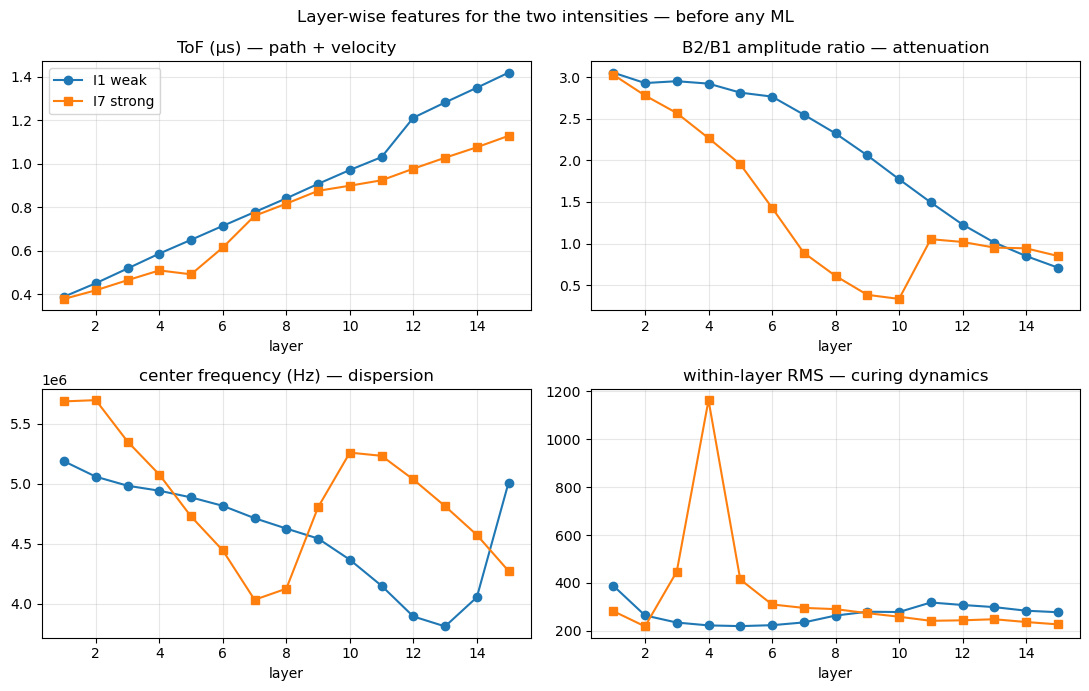

In [5]:
# Four features, one per physical mechanism (see the panel titles).
names = ["ToF", "amplitude", "Center_Freq", "frame_diff_rms"]
titles = ["ToF (µs) — path + velocity", "B2/B1 amplitude ratio — attenuation",
          "center frequency (Hz) — dispersion", "within-layer RMS — curing dynamics"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, n, ti in zip(axes.ravel(), names, titles):
    ax.plot(F1.index, F1[n], "o-", label="I1 weak", color="tab:blue")
    ax.plot(F7.index, F7[n], "s-", label="I7 strong", color="tab:orange")
    ax.set(title=ti, xlabel="layer"); ax.grid(alpha=0.3)
axes[0, 0].legend()
plt.suptitle("Layer-wise features for the two intensities — before any ML")
plt.tight_layout(); plt.show()


**Read the four panels like a physicist** — and notice where the physics is
clear and where it is not:

- *ToF* rises in both prints, because the path keeps growing. It rises more
  slowly for I7 (about 0.057 versus 0.074 µs per layer): the strongly cured
  material carries sound faster, so each added layer costs less time. This is
  the cleanest, most reliable signal we have.
- *Amplitude ratio* falls in both prints, and over the first ten layers it
  falls much faster for I7 — the more crosslinked network attenuates more.
  Look closely at I7 around layer 11, though: the ratio jumps back up instead
  of continuing down. That discontinuity is almost certainly the echo tracker
  latching onto a neighbouring peak in a weak signal, not a material effect.
  Treat it as a reminder that every feature inherits the tracker's mistakes.
- *Center frequency* drifts downward in both prints but along clearly different
  paths; I7 starts higher and ends lower. The two prints are distinguishable
  here, but not by a simple "one is always above the other" rule.
- *Within-layer RMS* does **not** separate the two prints cleanly at this
  scale. Both sit in the same few-hundred-count range, and I7 shows an isolated
  spike around layer 4. From this pair of prints alone you should conclude
  nothing about how within-layer motion depends on exposure — which is exactly
  why the next section looks at all 50 prints, and why Notebook 3 refuses to
  trust any of these impressions without a leak-free test.

## 3. Where the dataset's features actually live

Everything so far was recomputed, in front of you, from three sample prints.
The rest of the series does not work that way: Notebooks 3 and 4 use the
**paper's own feature table**, covering all 50 printed cylinders, exactly as it
was produced by the published extraction pipeline. It is worth knowing precisely
what that file is before we start modelling with it.

**`data/feature11.csv` — the feature table.** One row per printed sample, 50
rows in total. Its columns are:

- `layer` — how many layers that cylinder has (10, 15, 20, 25 or 30);
- `intensity` — the exposure intensity, stored as **percent of maximum lamp
  power**, so 10 = I1 = 10.70 mW/cm² and 70 = I7 = 20.16 mW/cm²;
- `Layer_{i}_{feature}` for i = 1…30 and the 11 features listed in section 2 —
  **330 columns**, holding the whole layer-by-layer history of the print;
- a copy of the three labels, for convenience.

The layer block is a fixed-width slot system: 30 slots regardless of how many
layers the print actually has. A 15-layer cylinder fills slots 1–15 and leaves
slots 16–30 at **zero**. That zero padding is what lets 50 prints of five
different heights live in one rectangular table and be fed to one network — and
it is also a trap: any statistic you compute over all 30 slots (a mean, a slope)
must be restricted to the print's real layers, or the padding will drag it
toward zero. You will see that guard written explicitly in `part_scale_stats()`
and again in Notebook 4.

**`data/condition_labels.csv` — the ground truth.** The same 50 rows in the same
order, with the three measured properties: `thickness` in mm from a Keyence
laser profilometer, `modulus` in Pa from a rheometer, and `DoC` (dimensionless,
0–1) from Raman spectroscopy. These come from offline, largely destructive
measurements made *after* printing — the very measurements the ultrasonic
sensor is meant to replace. This file is the authoritative copy of the labels,
and it is the one Notebook 3 merges in.

Both files are derived data. The raw waveforms behind them — every layer of all
50 prints, at 6 frames and 62,509 points each — are hundreds of megabytes and
stay in the authors' archive; `DATA_CARD.md` documents the provenance, and the
three `.npz` files you have been using are a small, read-only excerpt of it.

---

**Input** — `data/feature11.csv`.

**What this cell does** — loads the table and inspects its structure: overall
shape, the list of features stored per layer slot, and one concrete print's ToF
sequence showing where the real layers stop and the zero padding begins. This is
an inspection, not a validation — we are looking at the file we are about to
model with.

**Output** — the printed structure, and `df`, the table used by the heatmaps in
section 4 and by both remaining notebooks.


In [6]:
import re

# The paper's own feature table: 50 rows (one per printed sample), wide format
# with columns Layer_1_ToF ... Layer_30_within_layer_std.
df = iu.load_features("data/feature11.csv")
print("table shape (rows = printed samples, columns):", df.shape)
print("non-layer columns:", [c for c in df.columns if not c.startswith("Layer_")])

# Which features are stored for each of the 30 layer slots?
bases = sorted({re.match(r"Layer_(\d+)_(.+)", c).group(2)
                for c in df.columns if c.startswith("Layer_")})
print(f"\n{len(bases)} features per layer slot:")
for b in bases:
    print("   ", b)

# Zero padding, made concrete: this print has 15 layers, so slots 16-30 are 0.
row = df[(df.layer == 15) & (df.intensity == 10)].iloc[0]
print("\n15-layer print at 10% lamp power — stored ToF per layer slot (µs):")
print("   slots  1- 3:", [round(float(row[f"Layer_{i}_ToF"]), 3) for i in (1, 2, 3)])
print("   slots 14-17:", [round(float(row[f"Layer_{i}_ToF"]), 3) for i in (14, 15, 16, 17)],
      "<- slots 16+ are zero padding")


table shape (rows = printed samples, columns): (50, 336)
non-layer columns: ['layer', 'intensity', 'thickness', 'modulus', 'DoC', 'sample_id']

11 features per layer slot:
    Bandwidth
    Center_Freq
    RMS_Energy
    ToF
    Wavelet_Energy_L0
    Wavelet_Energy_L1
    Wavelet_Energy_L2
    Wavelet_Energy_L3
    amplitude
    frame_diff_rms
    within_layer_std

15-layer print at 10% lamp power — stored ToF per layer slot (µs):
   slots  1- 3: [0.414, 0.473, 0.542]
   slots 14-17: [1.207, 1.255, 0.0, 0.0] <- slots 16+ are zero padding


## 4. The whole design grid at a glance — feature heatmaps

Now use the full 50-sample table: layer × intensity heatmaps for one layer-count
group (the paper's Fig. 9/11 style). This is the honest way to ask the question
the previous section could not answer — does a feature respond to exposure
*across the whole design*, or did we read a trend into two prints?

---

**Input** — the complete `feature11.csv` table (`df`), not just our three
prints. We use the **30-layer group**: 10 prints, one per intensity I1…I10, each
with 30 filled layer slots.

**What this cell does** — for a chosen feature, gathers the 10 rows into a
matrix of shape (30 layers × 10 intensities) and draws it as an image: vertical
axis = depth into the print, horizontal axis = light dose.

**Output** — three heatmaps, and a printed column-average per intensity so the
trends can be checked as numbers instead of as colours. What they show:

- **ToF** has a strong, obvious gradient *down* the image — the part growing.
  Geometry dominates this feature completely.
- **Amplitude ratio** also varies mostly with depth. Its averages across
  I1→I10 move around (roughly 0.6 → 1.2 → 1.0) without a clean monotonic dose
  trend, so the "more dose → more attenuation" pattern we saw in the I1/I7 pair
  does **not** simply extend across the whole design.
- **Within-layer RMS** is close to flat across exposure: the intensity-averaged
  values sit within a few percent of each other. Whatever cure information it
  carries is not a simple one-dimensional response to lamp power.

This is a genuinely useful negative result, and it sets up the rest of the
series. No single feature reads out the process state on its own. The paper's
answer is not a better feature but a **model over many features at once**, held
to an evaluation protocol that cannot reward wishful reading — which is exactly
what Notebook 3 builds.


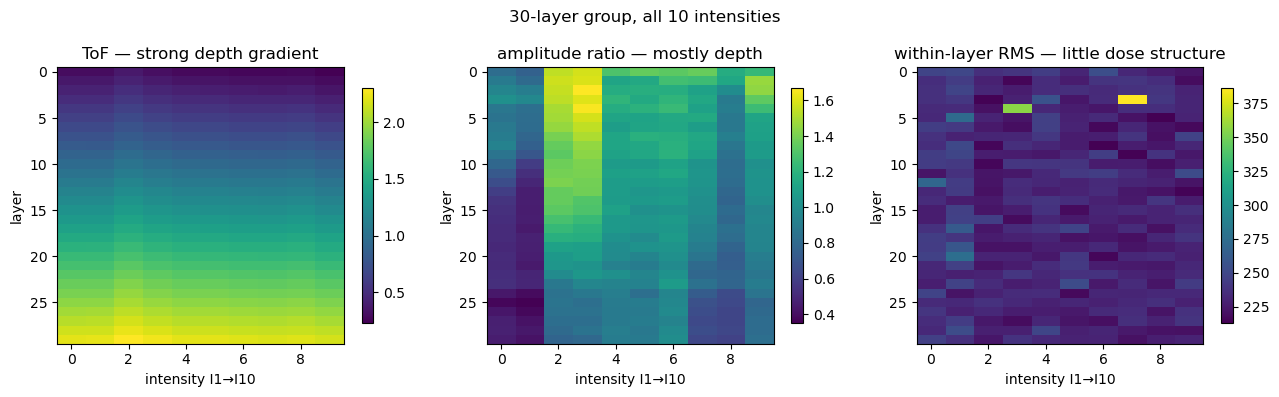

column average over the 30 layers, for intensities I1 -> I10:
  ToF             [1.256 1.256 1.332 1.281 1.246 1.244 1.227 1.222 1.237 1.192]
  amplitude       [0.653 0.576 1.224 1.256 1.049 1.041 1.09  0.959 0.813 1.019]
  frame_diff_rms  [238.159 244.034 226.703 233.549 235.22  231.107 230.484 234.881 228.319
 230.963]


In [7]:
def heat(ax, base, group_layers, title, cmap="viridis"):
    """Draw a (layer × intensity) heatmap of one feature for one layer group."""
    g = df[df.layer == group_layers].sort_values("intensity")   # 10 prints, I1..I10
    # Build the matrix column by column (one column per print), then transpose
    # so that rows = layers (depth) and columns = intensity (dose).
    M = np.array([[r[f"Layer_{i}_{base}"] for i in range(1, group_layers + 1)]
                  for _, r in g.iterrows()]).T          # layers × intensities
    im = ax.imshow(M, aspect="auto", origin="upper", cmap=cmap)
    ax.set(xlabel="intensity I1→I10", ylabel="layer", title=title)
    return im

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
BASES_SHOWN = ["ToF", "amplitude", "frame_diff_rms"]
for ax, base, ti in zip(axes, BASES_SHOWN,
        ["ToF — strong depth gradient", "amplitude ratio — mostly depth",
         "within-layer RMS — little dose structure"]):
    im = heat(ax, base, 30, ti)
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.suptitle("30-layer group, all 10 intensities")
plt.tight_layout(); plt.show()

# Check the colours as numbers: average each feature down the 30 layers, so what
# is left is its response to exposure alone.
g = df[df.layer == 30].sort_values("intensity")
print("column average over the 30 layers, for intensities I1 -> I10:")
for base in BASES_SHOWN:
    M = np.array([[r[f"Layer_{i}_{base}"] for i in range(1, 31)]
                  for _, r in g.iterrows()])
    print(f"  {base:15s}", np.round(M.mean(axis=1), 3))


## Exercises

1. Recreate the heatmaps for the 10-layer group. Does within-layer RMS depend
   on exposure there in any consistent way? Compare with the 30-layer group and
   state what evidence would convince you either way.
2. `iu.layer_features` uses the **last** frame of each layer for the
   across-layer features. Re-run section 2 using the *reference* frame
   (index 0) instead. Which features change most, and why?
3. Design ONE new feature you believe tracks curing but not geometry. Compute
   it for I1 vs I7 and defend your design in two sentences. *(You will test it
   properly — leak-free — after Notebook 3.)*

**Next notebook:** we assemble the 344-dimensional representation and learn —
without fooling ourselves.
